# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
The FIFA World Cup 2026 is the biggest football tournament in history.
The tournament is jointly hosted by the United States, Canada, and Mexico.
For the first time, forty-eight national teams are competing in the FIFA World Cup.
The tournament features one hundred and four matches across multiple host cities.
Millions of football fans from around the world are following the tournament.
The group stage is followed by exciting knockout matches.
Every team dreams of lifting the prestigious FIFA World Cup trophy.
The competition showcases the world's best football players and national teams.
Young stars and experienced veterans compete on the biggest stage in football.
Every match brings unforgettable moments, dramatic goals, and passionate celebrations.
The atmosphere inside the stadiums is filled with excitement and energy.
Supporters proudly wear their national colors and cheer for their favorite teams.
Football unites people from different countries, cultures, and backgrounds.
The FIFA World Cup inspires millions of young players to pursue their dreams.
Teams rely on teamwork, discipline, and determination to achieve success.
Coaches prepare tactical strategies for every opponent during the tournament.
Goalkeepers make crucial saves that can change the outcome of a match.
Forwards aim to score goals while defenders work to protect their team's lead.
Every victory brings a team one step closer to becoming world champions.
Winning the FIFA World Cup is considered the greatest achievement in international football.
'''
print(corpus)


The FIFA World Cup 2026 is the biggest football tournament in history.
The tournament is jointly hosted by the United States, Canada, and Mexico.
For the first time, forty-eight national teams are competing in the FIFA World Cup.
The tournament features one hundred and four matches across multiple host cities.
Millions of football fans from around the world are following the tournament.
The group stage is followed by exciting knockout matches.
Every team dreams of lifting the prestigious FIFA World Cup trophy.
The competition showcases the world's best football players and national teams.
Young stars and experienced veterans compete on the biggest stage in football.
Every match brings unforgettable moments, dramatic goals, and passionate celebrations.
The atmosphere inside the stadiums is filled with excitement and energy.
Supporters proudly wear their national colors and cheer for their favorite teams.
Football unites people from different countries, cultures, and backgrounds.
The FI

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 137
X shape: (211, 14)
y shape: (211,)


# 🧠 Model 1: Vanilla RNN

Vanilla Recurrent Neural Network (RNN) is the simplest sequence modeling architecture. It processes input one token at a time by maintaining a hidden state that carries information from previous time steps. However, due to the vanishing gradient problem, it struggles to learn long-term dependencies in lengthy sequences.

**Objective:**
- Build a baseline text generation model.
- Learn sequential patterns from the training corpus.
- Compare its performance with LSTM and GRU models.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: Long Short-Term Memory (LSTM)

Long Short-Term Memory (LSTM) networks overcome the limitations of Vanilla RNN by introducing memory cells and gating mechanisms. These gates enable the model to preserve important information over long sequences, making LSTM highly effective for language modeling and text generation.

**Objective:**
- Capture long-term contextual dependencies.
- Improve text generation quality over Vanilla RNN.
- Reduce the effects of the vanishing gradient problem.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: Gated Recurrent Unit (GRU)

Gated Recurrent Unit (GRU) is a simplified version of LSTM that combines the forget and input gates into a single update gate. GRUs require fewer parameters, train faster, and often achieve performance comparable to LSTMs.

**Objective:**
- Generate coherent text using a lightweight recurrent architecture.
- Compare efficiency and performance with Vanilla RNN and LSTM.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


# 📊 Training Loss Comparison

The training loss curves of the three recurrent neural network architectures are compared to evaluate their learning behavior during training.

This comparison helps analyze:
- Convergence speed
- Learning stability
- Sequence modeling capability
- Overall training performance

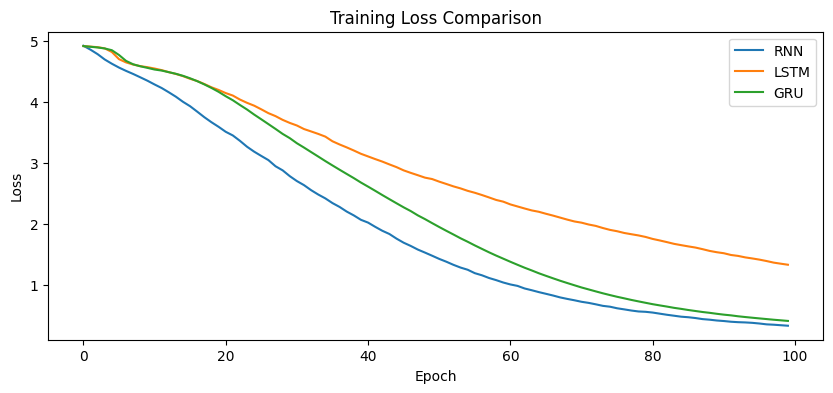

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation

After training, each model predicts the next word iteratively to generate meaningful text sequences from a given seed phrase. The generated text demonstrates how effectively each architecture has learned the grammar and contextual relationships present in the training corpus.

In [8]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [9]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning the fifa world cup inspires
LSTM: deep learning of of the fifa world
GRU : deep learning of the fifa world cup


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# Conclusion

This project demonstrates text generation using three recurrent neural network architectures: Vanilla RNN, LSTM, and GRU.

The Vanilla RNN serves as a simple baseline but struggles with long-term dependencies due to the vanishing gradient problem. LSTM addresses this limitation through memory cells and gating mechanisms, producing more coherent text. GRU offers similar performance with a simpler architecture and fewer parameters, making it computationally efficient.

Overall, recurrent neural networks are capable of learning language patterns and generating meaningful text, while advanced architectures such as LSTM and GRU provide superior sequence modeling capabilities.